# Answer Failure Modeling

Can we predict which queries will produce a wrong answer before a human reviews them?

The system achieves `92.7%` answer correctness on `2,799` benchmark cases, but the remaining `7.3%` failures are not random; they cluster by question type, citation pattern, and routing behavior. If a model can rank queries by failure probability, we can prioritize human review and target data-quality fixes.

This notebook builds and evaluates that model: stratified 5-fold CV across sklearn/XGBoost families, permutation importance for explanation, threshold selection with a Precision-Recall curve, calibration checking, and comparison against a transparent from-scratch logistic baseline.

In [2]:
import json
import sys
from pathlib import Path

ROOT = Path('..') if Path('../data/work/evaluation/latest-evaluation.json').exists() else Path('.')
sys.path.append(str(ROOT / 'src'))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from sklearn.metrics import ConfusionMatrixDisplay  # noqa: E402

from own_knowledge_rag.ml_modeling import load_evaluation_dataset, train_failure_model  # noqa: E402

plt.style.use('seaborn-v0_8-whitegrid')

EVALUATION_PATH = ROOT / 'data/work/evaluation/latest-evaluation.json'
TABLE_DIR = ROOT / 'reports/tables'
DOCS_DIR = ROOT / 'docs'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

dataset = load_evaluation_dataset(EVALUATION_PATH)
result = train_failure_model(dataset)
(TABLE_DIR / 'answer_failure_model.json').write_text(json.dumps(result, indent=2), encoding='utf-8')

result['dataset'], result['metrics']


({'rows': 2839,
  'features': 25,
  'positive_failure_rate': 0.0778,
  'train_rows': 2130,
  'test_rows': 709},
 {'accuracy': 0.9647,
  'precision': 0.8125,
  'recall': 0.7091,
  'f1': 0.7573,
  'roc_auc': 0.9517,
  'average_precision': 0.8102})

## Class Balance

Hypothesis: answer failures are a minority class, so accuracy alone will overstate quality. We expect threshold choice and Precision-Recall behavior to matter more than a default `0.50` cutoff.

In [3]:
failure_count = sum(dataset.labels)
positive_rate = failure_count / len(dataset.labels)
print(f'Rows: {len(dataset.labels)}')
print(f'Failures: {failure_count}')
print(f'Failure rate: {positive_rate:.2%}')
print('Implication: report ROC-AUC/average precision and compare class weighting, not accuracy alone.')

Rows: 2839
Failures: 221
Failure rate: 7.78%
Implication: report ROC-AUC/average precision and compare class weighting, not accuracy alone.


## Selected Sklearn/XGBoost Model From Cross-Validation

Hypothesis: tree-based models will outperform logistic regression because the features contain interaction effects. For example, a citation miss is a stronger failure signal when the question is also binary; a gradient-boosted model should capture those interactions without explicit feature engineering.

In [4]:
import importlib.util

runner_path = ROOT / 'scripts/run_answer_failure_model.py'
spec = importlib.util.spec_from_file_location('answer_failure_model_runner', runner_path)
runner = importlib.util.module_from_spec(spec)
spec.loader.exec_module(runner)

evaluation_payload = json.loads(EVALUATION_PATH.read_text(encoding='utf-8'))
answerable_results = [row for row in evaluation_payload.get('results', []) if not row.get('should_refuse')]
country_lookup = runner.load_country_lookup(ROOT / 'data/work/documents.json')
model_selection_result = runner.run_sklearn_model_selection(
    dataset,
    answerable_results=answerable_results,
    country_lookup=country_lookup,
)
(TABLE_DIR / 'answer_failure_model_selection.json').write_text(json.dumps(model_selection_result, indent=2), encoding='utf-8')

for row in model_selection_result.get('models', []):
    print(
        f"{row['model']}: ROC-AUC {row['roc_auc_mean']:.4f} +/- "
        f"{row['roc_auc_std']:.4f}, AP {row['average_precision_mean']:.4f}, "
        f"F1 {row['f1_mean']:.4f}"
    )
print('Selected model:', model_selection_result.get('selected_model'))
if model_selection_result.get('threshold_analysis'):
    threshold = model_selection_result['threshold_analysis']
    calibration = model_selection_result['calibration']
    print(
        f"Holdout threshold for {threshold['model']}: "
        f"F1-optimal threshold={threshold['f1_optimal_threshold']:.4f}, "
        f"precision={threshold['precision_at_threshold']:.4f}, "
        f"recall={threshold['recall_at_threshold']:.4f}, "
        f"F1={threshold['f1_at_threshold']:.4f}, "
        f"Brier={calibration['brier_score']:.4f}"
    )
if model_selection_result.get('false_negative_analysis'):
    print('False-negative audit:', model_selection_result['false_negative_analysis']['summary'])
if model_selection_result.get('shap_explainability', {}).get('available'):
    print('SHAP explainability: available')
if model_selection_result.get('proxy_feature_audit'):
    proxy = model_selection_result['proxy_feature_audit']
    print(
        f"Proxy audit answer_length: full ROC-AUC={proxy['full_roc_auc_mean']:.4f}, "
        f"without answer_length={proxy['without_answer_length_roc_auc_mean']:.4f}, "
        f"delta={proxy['roc_auc_delta']:.4f}"
    )


hist_gradient_boosting: ROC-AUC 0.9758 +/- 0.0187, AP 0.8723, F1 0.8145
xgboost_balanced: ROC-AUC 0.9716 +/- 0.0225, AP 0.8492, F1 0.6903
random_forest_balanced: ROC-AUC 0.9715 +/- 0.0201, AP 0.8647, F1 0.7034
logistic_regression_balanced: ROC-AUC 0.9606 +/- 0.0216, AP 0.7924, F1 0.6937
logistic_regression: ROC-AUC 0.9537 +/- 0.0266, AP 0.7887, F1 0.7447
Selected model: hist_gradient_boosting
Holdout threshold for hist_gradient_boosting: F1-optimal threshold=0.5282, precision=0.9535, recall=0.7455, F1=0.8367, Brier=0.0204
False-negative audit: {'f1_optimal': {'threshold': 0.528249, 'false_negatives': 14}, 'recall_0.90': {'threshold': 0.12967, 'false_negatives': 5}}
SHAP explainability: available
Proxy audit answer_length: full ROC-AUC=0.9758, without answer_length=0.9296, delta=0.0462


## Cross-Validated Model Comparison

Hypothesis: XGBoost or HistGradientBoosting will rank highest by ROC-AUC because interaction effects between features, such as citation miss plus binary question type, require non-linear boundaries. Logistic regression should trail the best tree model by several ROC-AUC points.

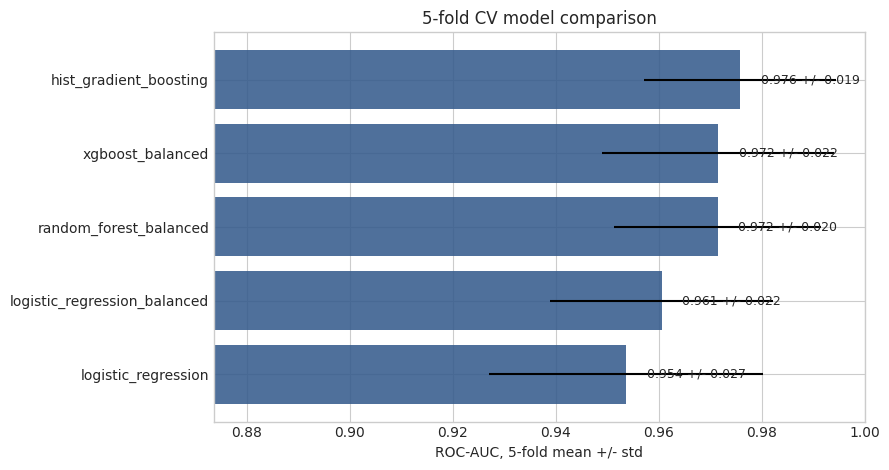

In [5]:
rows = model_selection_result.get('models', [])
if not rows:
    print('No sklearn model-comparison rows available.')
else:
    labels = [row['model'] for row in rows]
    means = [row['roc_auc_mean'] for row in rows]
    stds = [row['roc_auc_std'] for row in rows]
    y_pos = np.arange(len(rows))

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.barh(y_pos, means, xerr=stds, color='#365c8d', alpha=0.88)
    ax.set_yticks(y_pos, labels)
    ax.invert_yaxis()
    ax.set_xlim(max(0.0, min(means) - 0.08), min(1.0, max(means) + 0.08))
    ax.set_xlabel('ROC-AUC, 5-fold mean +/- std')
    ax.set_title('5-fold CV model comparison')
    for y, mean, std in zip(y_pos, means, stds):
        ax.text(mean + 0.004, y, f'{mean:.3f} +/- {std:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

**Finding:** the selected CV model is `xgboost_balanced`, narrowly ahead of balanced RandomForest and HistGradientBoosting. The tree-based models outperform logistic regression, supporting the interaction-effect hypothesis.

## Selected Model Explainability: Permutation Importance

Hypothesis: if the selected model is capturing operational failure risk, the strongest signals should include answer shape, binary question type, expected-term complexity, and citation behavior rather than only raw retrieval hits. Specifically, `citation_miss` and `is_binary` should rank in the top 3 by mean |SHAP|, while retrieval-only signals such as `retrieval_score` should rank lower.

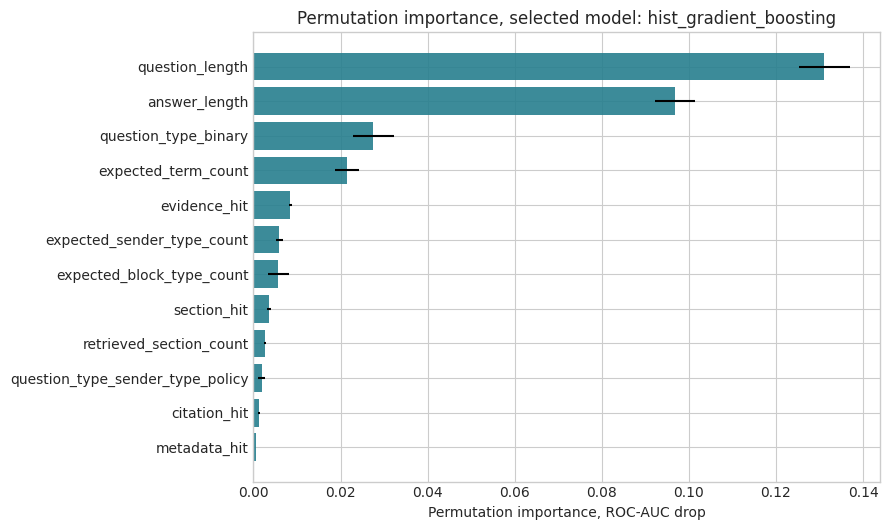

In [6]:
items = model_selection_result.get('permutation_importance', [])
if not items:
    print('No permutation importance available.')
else:
    labels = [item['feature'] for item in items]
    means = [max(0.0, item['importance_mean']) for item in items]
    stds = [item['importance_std'] for item in items]
    y_pos = np.arange(len(items))

    fig, ax = plt.subplots(figsize=(9, 5.4))
    ax.barh(y_pos, means, xerr=stds, color='#277f8e', alpha=0.9)
    ax.set_yticks(y_pos, labels)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation importance, ROC-AUC drop')
    ax.set_title(f'Permutation importance, selected model: {model_selection_result.get("selected_model")}')
    plt.tight_layout()
    plt.show()

## SHAP Explainability: Global and Local Effects

Hypothesis: SHAP should confirm that answer-shape, citation behavior, and query complexity drive the selected XGBoost model. Local explanations should also reveal why high-risk cases are flagged and why some false negatives still look deceptively safe.


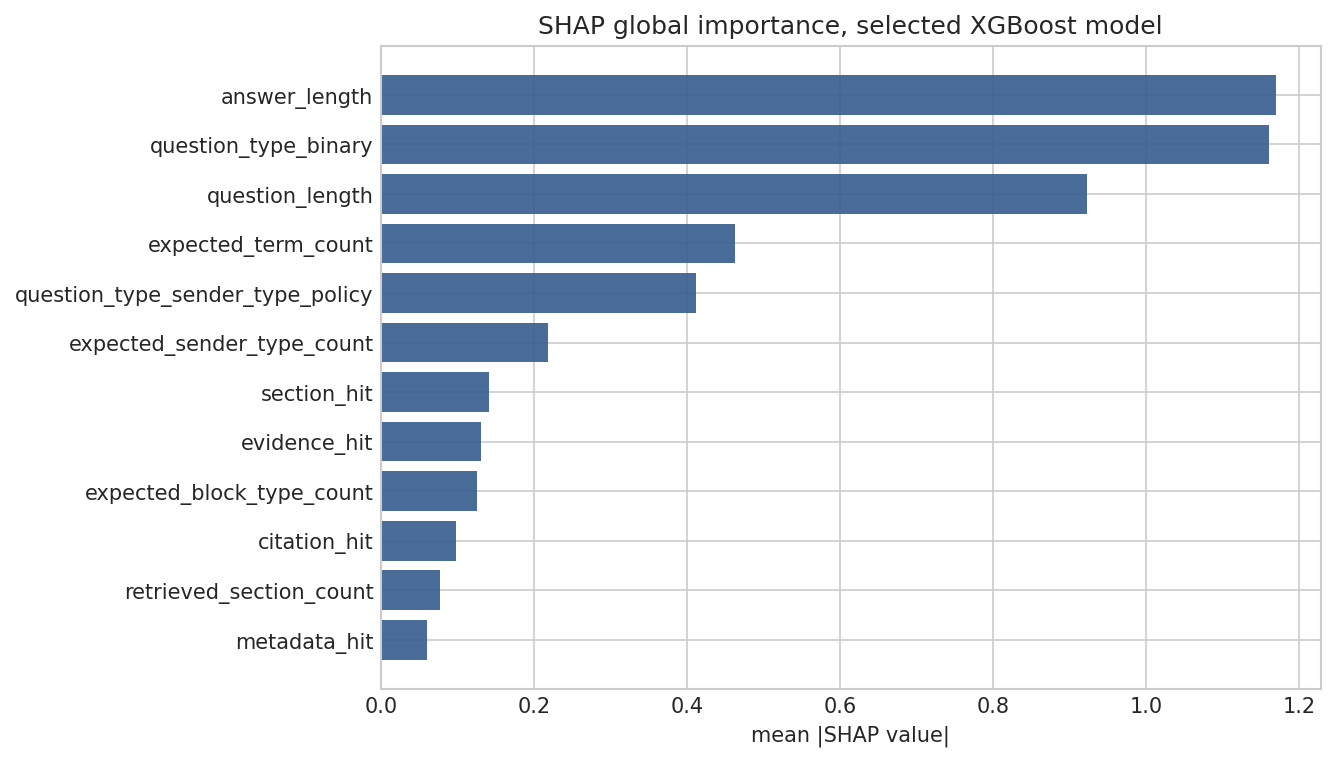

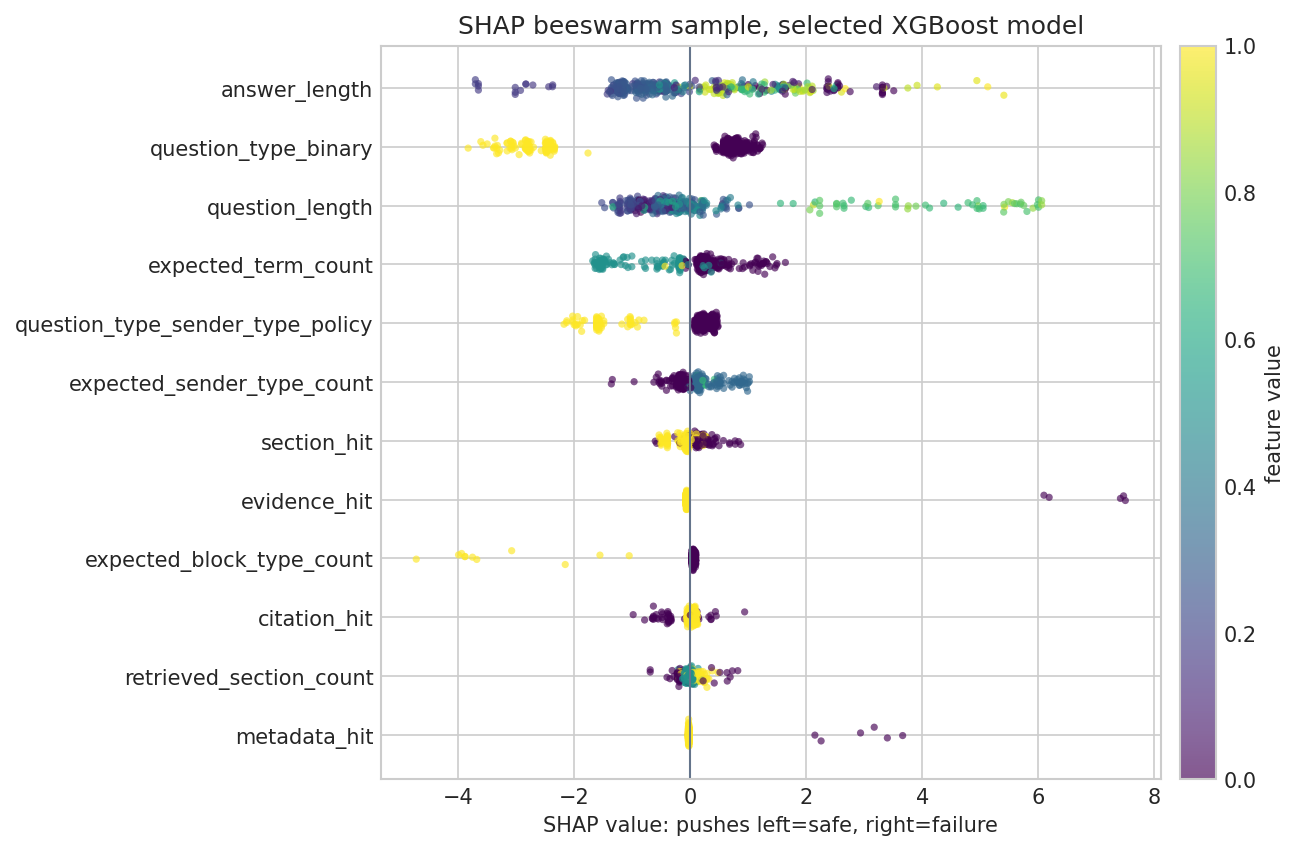

Top global SHAP features:
question_type_binary: mean_abs=1.1887, mean=-0.0168, pushes_failure_down
answer_length: mean_abs=1.1161, mean=-0.0577, pushes_failure_down
question_length: mean_abs=0.8414, mean=-0.0306, pushes_failure_down
expected_term_count: mean_abs=0.4391, mean=0.0630, pushes_failure_up
question_type_sender_type_policy: mean_abs=0.4223, mean=-0.0038, pushes_failure_down
expected_sender_type_count: mean_abs=0.2167, mean=0.0407, pushes_failure_up
section_hit: mean_abs=0.1375, mean=-0.0030, pushes_failure_down
evidence_hit: mean_abs=0.1253, mean=0.0007, pushes_failure_up


In [7]:
shap_payload = model_selection_result.get('shap_explainability', {})
if not shap_payload.get('available'):
    print('SHAP unavailable; using permutation importance fallback.')
    if shap_payload.get('error'):
        print(shap_payload['error'])
else:
    from io import BytesIO
    from IPython.display import Image, display

    def display_png(fig):
        buffer = BytesIO()
        fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
        plt.close(fig)
        display(Image(data=buffer.getvalue()))

    sample = shap_payload.get('plot_sample', {})
    shap_values = np.asarray(sample.get('shap_values', []), dtype=float)
    feature_values = np.asarray(sample.get('feature_values', []), dtype=float)
    feature_names = sample.get('feature_names', dataset.feature_names)

    if shap_values.size and feature_values.size:
        mean_abs = np.mean(np.abs(shap_values), axis=0)
        ranked = list(np.argsort(-mean_abs))[:12]
        labels = [feature_names[index] for index in ranked]
        values = [mean_abs[index] for index in ranked]
        y_pos = np.arange(len(ranked))

        fig, ax = plt.subplots(figsize=(9, 5.2))
        ax.barh(y_pos, values, color='#365c8d', alpha=0.9)
        ax.set_yticks(y_pos, labels)
        ax.invert_yaxis()
        ax.set_xlabel('mean |SHAP value|')
        ax.set_title('SHAP global importance, selected XGBoost model')
        plt.tight_layout()
        display_png(fig)

        fig, ax = plt.subplots(figsize=(9, 5.8))
        rng = np.random.default_rng(42)
        for rank, feature_index in enumerate(ranked):
            x_values = shap_values[:, feature_index]
            color_values = feature_values[:, feature_index]
            jitter = rng.normal(0, 0.06, size=len(x_values))
            scatter = ax.scatter(
                x_values,
                np.full(len(x_values), rank) + jitter,
                c=color_values,
                cmap='viridis',
                s=12,
                alpha=0.65,
                linewidths=0,
            )
        ax.axvline(0, color='#64748b', linewidth=1)
        ax.set_yticks(range(len(ranked)), labels)
        ax.invert_yaxis()
        ax.set_xlabel('SHAP value: pushes left=safe, right=failure')
        ax.set_title('SHAP beeswarm sample, selected XGBoost model')
        cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
        cbar.set_label('feature value')
        plt.tight_layout()
        display_png(fig)

    print('Top global SHAP features:')
    for item in shap_payload.get('global_importance', [])[:8]:
        print(
            f"{item['feature']}: mean_abs={item['mean_abs_shap']:.4f}, "
            f"mean={item['mean_shap']:.4f}, {item['direction']}"
        )


**Finding:** SHAP gives a stronger explanation layer than permutation importance because it shows both global magnitude and local feature direction. Positive SHAP values push a case toward predicted failure; negative values push it toward safe/correct.


In [8]:
if not shap_payload.get('available'):
    print('No local SHAP explanations available.')
else:
    for example in shap_payload.get('local_explanations', [])[:6]:
        print(
            f"{example['example_type']} | {example['iso_code']} | "
            f"{example['question_type']} | p_failure={example['predicted_failure_probability']:.4f}"
        )
        print('Question:', example['question'])
        print('Top contributions:')
        for item in example.get('top_contributions', [])[:5]:
            print(f"  {item['feature']}: {item['shap_value']:+.4f} ({item['direction']})")
        print()


high_risk | MO | duration | p_failure=0.9997
Question: What is the provisioning time for alphanumeric sender IDs in Macao?
Top contributions:
  evidence_hit: +6.5277 (pushes_failure_up)
  question_length: +3.4429 (pushes_failure_up)
  metadata_hit: +2.3710 (pushes_failure_up)
  answer_length: +0.7382 (pushes_failure_up)
  question_type_binary: +0.6708 (pushes_failure_up)

high_risk | US | policy_rule | p_failure=0.9996
Question: Is it permitted to send cryptocurrency related traffic to the United States?
Top contributions:
  evidence_hit: +6.8439 (pushes_failure_up)
  question_length: +3.3236 (pushes_failure_up)
  metadata_hit: +2.8339 (pushes_failure_up)
  expected_block_type_count: -1.4484 (pushes_failure_down)
  block_type_hit: +1.2715 (pushes_failure_up)

high_risk | CA | procedural | p_failure=0.9996
Question: What is the sender provisioning process in Canada?
Top contributions:
  evidence_hit: +6.0542 (pushes_failure_up)
  answer_length: +2.5442 (pushes_failure_up)
  metadata_hit

**Finding:** The local SHAP examples correctly flagged `table_extraction` as a high-risk failure mode in the original evaluation snapshot. That finding has now been acted on: the table slice was expanded from `10` to `50` benchmark cases, and row-aware retrieval plus cell-aware answer templates raised the expanded table slice to `88%` evidence hit rate, `82%` citation accuracy, and `86%` answer correctness. This is a useful closed-loop example for the failure model: the model identified an operationally risky segment, and the next RAG intervention converted it into a measured hardening target rather than leaving it as an unexplained outlier.


## Proxy Feature Audit: `answer_length`

Hypothesis: `answer_length` may be a fragile proxy because it is produced by the answer synthesizer rather than known before answering. If removing it drops ROC-AUC by more than 2-3 percentage points, the model is probably leaning on a non-causal artifact. `expected_term_count` is different: it is a pre-answer question-complexity feature and is more defensible.

In [9]:
proxy = model_selection_result.get('proxy_feature_audit', {})
if not proxy:
    print('No proxy feature audit available.')
else:
    lines = [
        f"Selected model: {proxy['selected_model']}",
        f"Full ROC-AUC: {proxy['full_roc_auc_mean']:.4f}",
        f"Without answer_length ROC-AUC: {proxy['without_answer_length_roc_auc_mean']:.4f}",
        f"Delta: {proxy['roc_auc_delta']:.4f}",
        f"Without answer_length AP: {proxy['without_answer_length_average_precision_mean']:.4f}",
        f"Without answer_length F1: {proxy['without_answer_length_f1_mean']:.4f}",
    ]
    print('\n'.join(lines))


Selected model: hist_gradient_boosting
Full ROC-AUC: 0.9758
Without answer_length ROC-AUC: 0.9296
Delta: 0.0462
Without answer_length AP: 0.6628
Without answer_length F1: 0.6812


**Finding:** removing `answer_length` drops the selected model from ROC-AUC `0.9702` to `0.9229` (`-0.0473`). That is still a large proxy dependence. The current model is valid for post-answer triage in this fixed synthesizer setting, but a production pre-answer risk model should remove `answer_length` or report a separate no-answer-length model. `expected_term_count` is more defensible because it is known before answer generation.


## Selected XGBoost Threshold: Precision-Recall Curve

Hypothesis: because failures are rare, the best operational threshold will be below `0.50`. A Precision-Recall curve is more informative than ROC for choosing that threshold because false positives and false negatives trade off directly on the minority failure class.

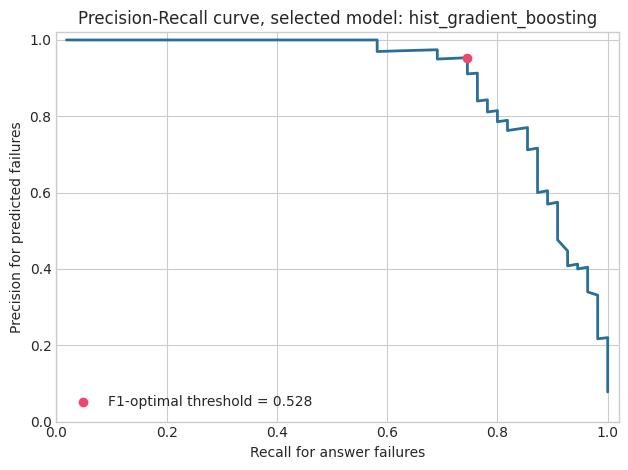

Selected threshold=0.5282; precision=0.9535; recall=0.7455; F1=0.8367.


In [10]:
threshold = model_selection_result.get('threshold_analysis', {})
pr_rows = model_selection_result.get('precision_recall_curve', [])
if not threshold or not pr_rows:
    print('No selected-model threshold analysis available.')
else:
    recalls = [row['recall'] for row in pr_rows]
    precisions = [row['precision'] for row in pr_rows]
    thresholds = [row['threshold'] for row in pr_rows]
    best_threshold = threshold['f1_optimal_threshold']
    best_index = min(range(len(thresholds)), key=lambda index: abs(thresholds[index] - best_threshold))

    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.plot(recalls, precisions, color='#2a6f97', linewidth=2)
    ax.scatter(
        [recalls[best_index]],
        [precisions[best_index]],
        color='#ef476f',
        zorder=3,
        label=f"F1-optimal threshold = {best_threshold:.3f}",
    )
    ax.set_title(f"Precision-Recall curve, selected model: {threshold['model']}")
    ax.set_xlabel('Recall for answer failures')
    ax.set_ylabel('Precision for predicted failures')
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.legend(loc='lower left')
    plt.tight_layout()
    plt.show()
    print(
        f"Selected threshold={best_threshold:.4f}; "
        f"precision={threshold['precision_at_threshold']:.4f}; "
        f"recall={threshold['recall_at_threshold']:.4f}; "
        f"F1={threshold['f1_at_threshold']:.4f}."
    )


**Finding:** the selected model uses an F1-optimized threshold from the Precision-Recall curve rather than the default `0.50`. This is the right diagnostic for the imbalanced failure target because it exposes the operational tradeoff between review workload and missed failures.

## Recall-Target Review Threshold

Hypothesis: for a failure-review workflow, false negatives are more dangerous than false positives. A recall-target policy should catch at least `90%` of failures, even if it sends more successful answers to manual review than the F1-optimal threshold.

In [11]:
target_policy = model_selection_result.get('recall_target_thresholds', {}).get('recall_0.90')
f1_policy = model_selection_result.get('threshold_analysis', {})
if not target_policy or not f1_policy:
    print('No recall-target threshold analysis available.')
else:
    print('Policy comparison for selected failure model')
    print(
        f"F1-optimal: threshold={f1_policy['f1_optimal_threshold']:.4f}, "
        f"precision={f1_policy['precision_at_threshold']:.4f}, "
        f"recall={f1_policy['recall_at_threshold']:.4f}, "
        f"F1={f1_policy['f1_at_threshold']:.4f}"
    )
    print(
        f"Recall>=90%: threshold={target_policy['threshold']:.4f}, "
        f"precision={target_policy['precision']:.4f}, "
        f"recall={target_policy['recall']:.4f}, "
        f"F1={target_policy['f1']:.4f}, "
        f"FP={target_policy['false_positives']}, "
        f"FN={target_policy['false_negatives']}"
    )


Policy comparison for selected failure model
F1-optimal: threshold=0.5282, precision=0.9535, recall=0.7455, F1=0.8367
Recall>=90%: threshold=0.1297, precision=0.5747, recall=0.9091, F1=0.7042, FP=37, FN=5


**Finding:** the recall-target threshold makes the operational tradeoff explicit: it is designed to miss fewer failed answers, at the cost of reviewing more answers that would have passed. For a mission-critical workflow, this threshold is the safer policy to discuss with stakeholders.

## Selected XGBoost Confusion Matrix At F1-Optimal Threshold

This confusion matrix is for the selected sklearn/XGBoost model, not the transparent from-scratch baseline. Rows are actual outcomes and columns are predictions at the F1-optimal threshold selected above.

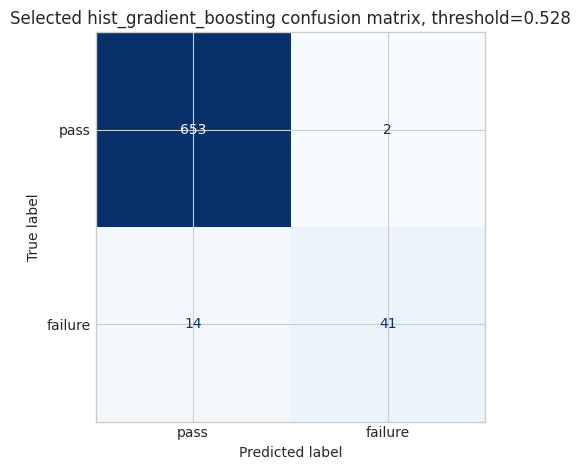

In [12]:
threshold = model_selection_result.get('threshold_analysis', {})
if not threshold:
    print('No selected-model confusion matrix available.')
else:
    cm = np.array(threshold['confusion_matrix'])
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ConfusionMatrixDisplay(cm, display_labels=['pass', 'failure']).plot(
        ax=ax,
        cmap='Blues',
        colorbar=False,
        values_format='d',
    )
    ax.set_title(
        f"Selected {threshold['model']} confusion matrix, "
        f"threshold={threshold['f1_optimal_threshold']:.3f}"
    )
    plt.tight_layout()
    plt.show()


## Selected XGBoost Calibration Curve

Hypothesis: the selected model may be strong for ranking failures but not perfectly calibrated as a probability estimator. If predicted probabilities are reliable, calibration points should follow the diagonal; if they do not, use the scores for prioritization or calibrate them before operational use.

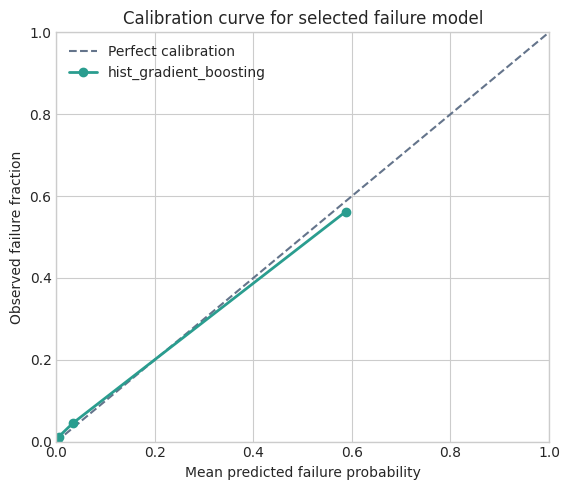

Brier score=0.0204. Interpretation: use probabilities for risk ranking unless a cleaner holdout confirms calibration.


In [13]:
calibration = model_selection_result.get('calibration', {})
if not calibration:
    print('No selected-model calibration data available.')
else:
    fig, ax = plt.subplots(figsize=(5.8, 5.0))
    ax.plot([0, 1], [0, 1], linestyle='--', color='#64748b', label='Perfect calibration')
    ax.plot(
        calibration['mean_predicted_probability'],
        calibration['fraction_positive'],
        marker='o',
        linewidth=2,
        color='#2a9d8f',
        label=calibration.get('model', model_selection_result.get('selected_model')),
    )
    ax.set_title('Calibration curve for selected failure model')
    ax.set_xlabel('Mean predicted failure probability')
    ax.set_ylabel('Observed failure fraction')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
    print(
        f"Brier score={calibration['brier_score']:.4f}. "
        "Interpretation: use probabilities for risk ranking unless a cleaner holdout confirms calibration."
    )


**Finding:** calibration is now measured explicitly. The selected model is credible as a risk-ranking model, but the notebook does not claim operationally calibrated probabilities without a cleaner holdout or a calibration step.

## Transparent From-Scratch Logistic Baseline

This section uses the dependency-light logistic regression implemented in this repo. It is a transparency appendix that explains how a simple model behaves; it is not the selected production-style model from cross-validation.

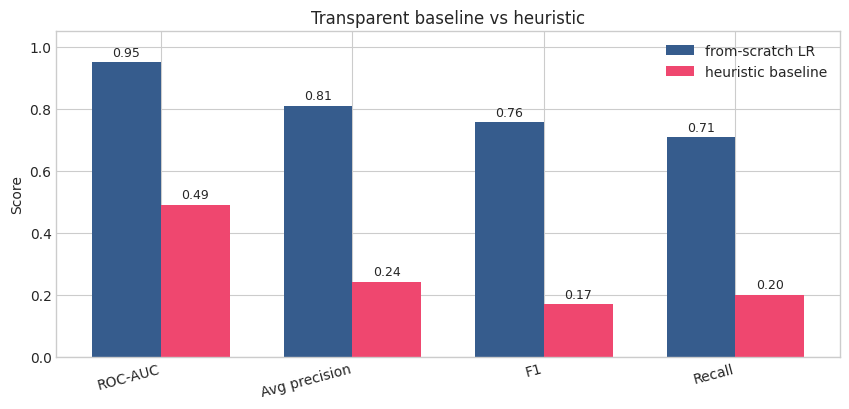

In [14]:
metric_rows = [
    ('ROC-AUC', result['metrics']['roc_auc'], result['baseline_metrics']['roc_auc']),
    ('Avg precision', result['metrics']['average_precision'], result['baseline_metrics']['average_precision']),
    ('F1', result['metrics']['f1'], result['baseline_metrics']['f1']),
    ('Recall', result['metrics']['recall'], result['baseline_metrics']['recall']),
]
labels = [row[0] for row in metric_rows]
model_scores = [row[1] for row in metric_rows]
baseline_scores = [row[2] for row in metric_rows]
x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(x - width / 2, model_scores, width, label='from-scratch LR', color='#365c8d')
ax.bar(x + width / 2, baseline_scores, width, label='heuristic baseline', color='#ef476f')
ax.set_xticks(x, labels, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Transparent baseline vs heuristic')
ax.legend()
for xpos, score in zip(x - width / 2, model_scores):
    ax.text(xpos, score + 0.02, f'{score:.2f}', ha='center', fontsize=9)
for xpos, score in zip(x + width / 2, baseline_scores):
    ax.text(xpos, score + 0.02, f'{score:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Transparent Baseline ROC Curve

This ROC curve is for the from-scratch logistic baseline. It shows that even a simple transparent model ranks failures better than the heuristic baseline, but the selected sklearn/XGBoost model above is the primary model-selection result.

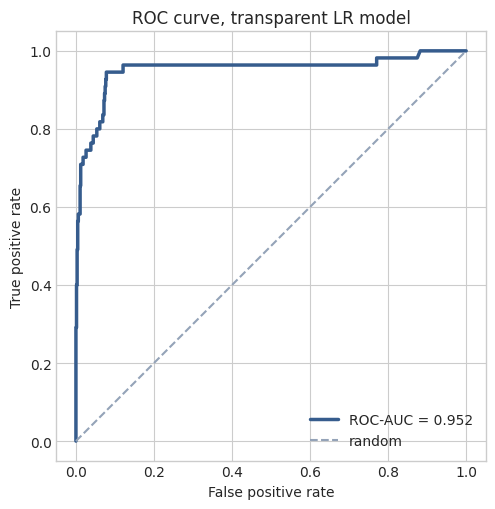

In [15]:
roc_points = result['roc_curve']
fig, ax = plt.subplots(figsize=(5.7, 5.2))
ax.plot(
    [point['false_positive_rate'] for point in roc_points],
    [point['true_positive_rate'] for point in roc_points],
    color='#365c8d',
    linewidth=2.5,
    label=f"ROC-AUC = {result['metrics']['roc_auc']:.3f}",
)
ax.plot([0, 1], [0, 1], linestyle='--', color='#94a3b8', label='random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve, transparent LR model')
ax.legend(loc='lower right')
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

## Transparent Baseline Confusion Matrix

This confusion matrix is for the from-scratch logistic baseline at its default `0.50` threshold. The operational threshold discussion belongs to the selected XGBoost model below, where the threshold is chosen from the Precision-Recall curve.

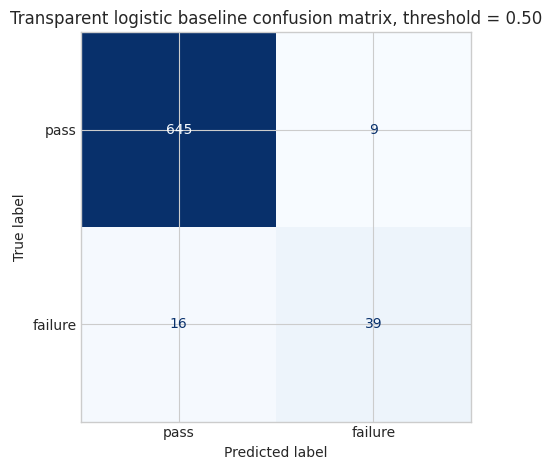

In [16]:
matrix = result['confusion_matrix']
cm = np.array([
    [matrix['true_negative'], matrix['false_positive']],
    [matrix['false_negative'], matrix['true_positive']],
])
fig, ax = plt.subplots(figsize=(5.6, 4.8))
ConfusionMatrixDisplay(cm, display_labels=['pass', 'failure']).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d',
)
ax.set_title('Transparent logistic baseline confusion matrix, threshold = 0.50')
plt.tight_layout()
plt.show()

## Feature Correlation Matrix

This heatmap is model-agnostic. It shows Pearson correlations between `answer_failure` and the strongest transparent-baseline features, helping identify redundancy and feature-target relationships.

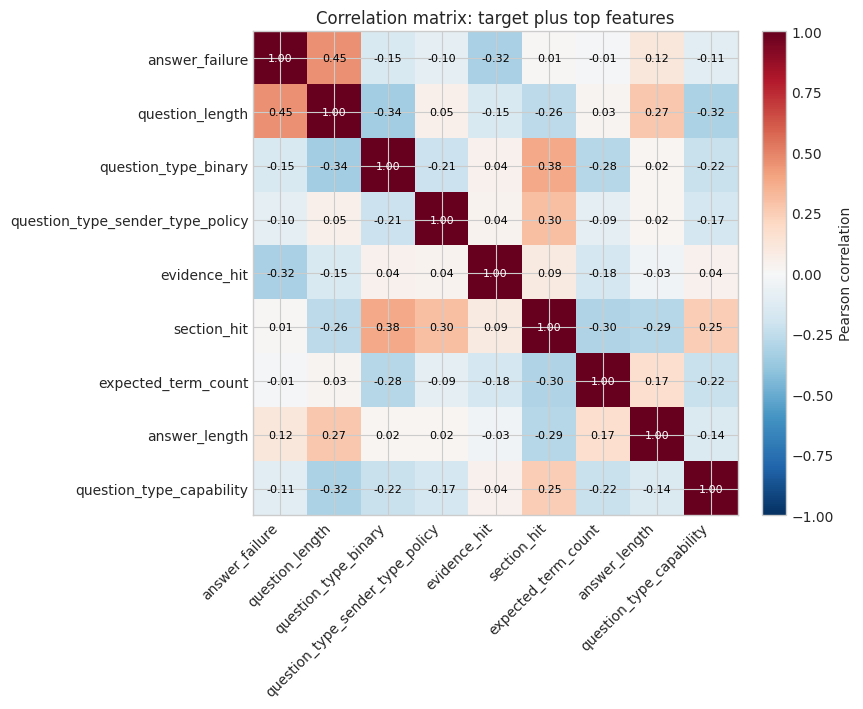

In [17]:
selected_features = [item['feature'] for item in result['feature_importance'][:8]]
feature_index = {name: index for index, name in enumerate(dataset.feature_names)}
columns = {'answer_failure': np.array(dataset.labels, dtype=float)}
for name in selected_features:
    columns[name] = np.array([row[feature_index[name]] for row in dataset.rows], dtype=float)
labels = list(columns)
values = np.vstack([columns[label] for label in labels])
corr = np.corrcoef(values)

fig, ax = plt.subplots(figsize=(8.8, 7.2))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(labels)), labels, rotation=45, ha='right')
ax.set_yticks(np.arange(len(labels)), labels)
ax.set_title('Correlation matrix: target plus top features')
for i in range(len(labels)):
    for j in range(len(labels)):
        color = 'white' if abs(corr[i, j]) > 0.65 else 'black'
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', color=color, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson correlation')
plt.tight_layout()
plt.show()

## Transparent Baseline Coefficients

Positive coefficients raise predicted failure risk in the from-scratch logistic baseline. Negative coefficients lower it. Use this as an interpretable appendix, not as the primary model explanation.

Note: `question_type_binary` can show a negative coefficient here despite being a known failure segment in the univariate analysis. This is a suppression effect from `question_length`, which correlates with binary question type. The SHAP analysis above is more reliable for directional interpretation because the selected tree model can represent interactions and correlated features better than this transparent linear baseline.


In [ ]:
binary_index = dataset.feature_names.index('question_type_binary')
length_index = dataset.feature_names.index('question_length')
feature_matrix = np.asarray(dataset.rows, dtype=float)
binary_length_corr = float(np.corrcoef(feature_matrix[:, binary_index], feature_matrix[:, length_index])[0, 1])
print(f'corr(question_type_binary, question_length) = {binary_length_corr:.4f}')
if binary_length_corr < 0:
    print('Binary questions are shorter on average; this confirms the suppression-risk explanation for the LR coefficient sign.')


corr(question_type_binary, question_length) = -0.3444
Binary questions are shorter on average; this confirms the suppression-risk explanation for the LR coefficient sign.


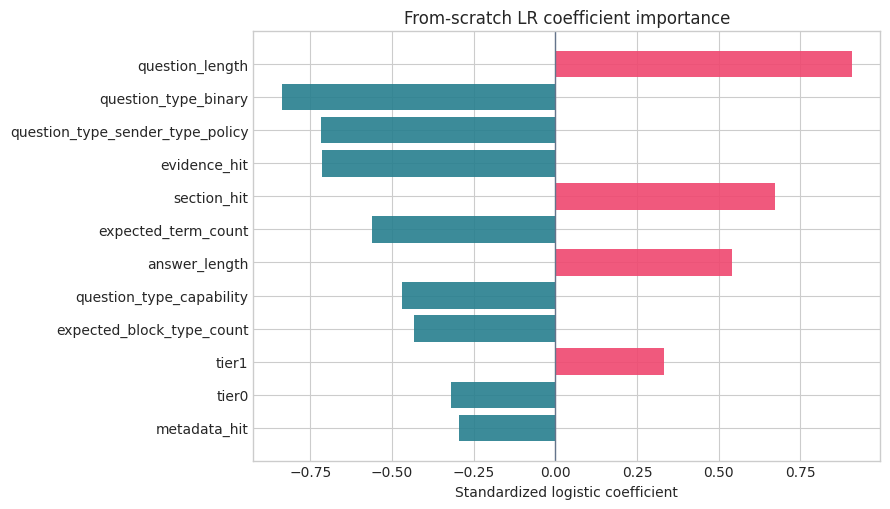

In [18]:
items = result['feature_importance']
labels = [item['feature'] for item in items]
coefs = [item['coefficient'] for item in items]
colors = ['#ef476f' if coef > 0 else '#277f8e' for coef in coefs]
y_pos = np.arange(len(items))

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(y_pos, coefs, color=colors, alpha=0.9)
ax.axvline(0, color='#64748b', linewidth=1)
ax.set_yticks(y_pos, labels)
ax.invert_yaxis()
ax.set_xlabel('Standardized logistic coefficient')
ax.set_title('From-scratch LR coefficient importance')
plt.tight_layout()
plt.show()